# Wildlife Camera Trap Detection with Bias-Reduced YOLO11

This notebook builds a **Kaggle-ready object detection pipeline** for the **Caltech Camera Traps (ECCV 2018)** dataset using **Ultralytics YOLO11**.

It includes:

- conversion from COCO JSON format to YOLO labels
- dataset preparation for the splits train, cis_val, trans_val, cis_test, and trans_test
- methods to reduce background bias, such as:
  - stronger colour and lighting augmentation for day/night changes
  - safe random cropping
  - coarse dropout / cutout-style occlusion
  - mosaic and cutmix
  - **early Instance Normalization**
  - **CBAM attention blocks**
- training with:
  - **trans_val as the main validation split**
  - **weighted classification loss** to handle class imbalance
  - **resume support**
  - **frozen early layers for a few warm-up epochs**
  - **W&B turned off**
- evaluation on both **cis_test** and **trans_test**
- qualitative prediction examples
- optional saliency visualization

> Recommended Kaggle settings: **GPU enabled**, internet optional.  
> This notebook uses **YOLO11s** by default because it is usually a practical choice for Kaggle GPUs while still supporting custom validation and stronger augmentation.

In [1]:

# If ultralytics / albumentations are already present, this cell does nothing.
# If your Kaggle environment is missing them and internet is enabled, this installs them.
import importlib.util
import sys
import subprocess

def ensure_pkg(spec_name, pip_name=None):
    if importlib.util.find_spec(spec_name) is None:
        pip_name = pip_name or spec_name
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

ensure_pkg("ultralytics", "ultralytics>=8.3.0")
ensure_pkg("albumentations", "albumentations>=1.4.0")
ensure_pkg("pycocotools", "pycocotools>=2.0.7")
ensure_pkg("yaml", "pyyaml>=6.0")
ensure_pkg("pandas", "pandas>=2.0.0")
ensure_pkg("matplotlib", "matplotlib>=3.7.0")
print("Package check complete.")


Installing ultralytics>=8.3.0 ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.3 MB/s eta 0:00:00
Package check complete.


In [2]:

import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import gc
import json
import math
import random
import shutil
from collections import Counter, defaultdict
from copy import deepcopy
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import yaml
import torch

from ultralytics import YOLO
import ultralytics
print("Ultralytics version:", ultralytics.__version__)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.47
Torch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 1) Paths and configs

In [3]:
# =========================
# DATA PATHS
# =========================
KAGGLE_IMAGE_ROOT = Path("/kaggle/input/datasets/jajaganj/wildlife/eccv_18_all_images_sm")
KAGGLE_ANN_ROOT = Path("/kaggle/input/datasets/jajaganj/wildlife-annotations/eccv_18_annotation_files")

ANN_PATHS = {
    "train": KAGGLE_ANN_ROOT / "train_annotations.json",
    "cis_val": KAGGLE_ANN_ROOT / "cis_val_annotations.json",
    "trans_val": KAGGLE_ANN_ROOT / "trans_val_annotations.json",
    "cis_test": KAGGLE_ANN_ROOT / "cis_test_annotations.json",
    "trans_test": KAGGLE_ANN_ROOT / "trans_test_annotations.json",
}

# =========================
# WORKSPACE
# =========================
WORKDIR = Path("/kaggle/working/wildlife_yolo11_biasaware")
DATASET_DIR = WORKDIR / "dataset_yolo"
IMAGES_DIR = DATASET_DIR / "images"
LABELS_DIR = DATASET_DIR / "labels"
CONFIG_DIR = WORKDIR / "configs"
ARTIFACT_DIR = WORKDIR / "artifacts"
RUN_NAME = "yolo11s_cbam_mapped_transval_v2"

for p in [WORKDIR, DATASET_DIR, IMAGES_DIR, LABELS_DIR, CONFIG_DIR, ARTIFACT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# =========================
# TRAINING SETTINGS
# =========================
SEED = 42
MODEL_SCALE = "s"          # "s" or "m"
BASE_MODEL_PT = f"yolo11{MODEL_SCALE}.pt"
CUSTOM_MODEL_YAML = CONFIG_DIR / f"custom_yolo11{MODEL_SCALE}_wildlife.yaml"
MAPPED_PRETRAINED_PT = CONFIG_DIR / f"custom_yolo11{MODEL_SCALE}_mapped_pretrained.pt"
REBUILD_MAPPED_PRETRAINED = True

# If the CCT baseline checkpoint from your other notebook is attached, use it as
# the source for the architecture transplant. Otherwise the code falls back to
# the public YOLO11 checkpoint and remaps the matching backbone/neck layers.
CCT_BASELINE_PT = Path("/kaggle/input/models/muneeb413/bestmodule1/pytorch/default/1/best.pt")
PRETRAINED_SOURCE_PT = CCT_BASELINE_PT if CCT_BASELINE_PT.exists() else BASE_MODEL_PT

IMG_SIZE = 640
EPOCHS = 60
BATCH = 8
WORKERS = 4
PATIENCE = 15

OPTIMIZER = "AdamW"
LR0 = 8e-4
LRF = 1e-2
WEIGHT_DECAY = 5e-4
WARMUP_EPOCHS = 3.0
COS_LR = True

# Do not freeze by default. The previous version froze newly inserted InstanceNorm
# and CBAM layers while they were still randomly initialized.
FREEZE_LAYERS = 0
FREEZE_EPOCHS = 0
PRIMARY_VAL_SPLIT = "trans_val"

KEEP_EMPTY_TRAIN_FRAC = 0.25
FILTER_TINY_BOXES_PX = 4

CLASS_WEIGHT_MODE = "inverse_sqrt"   # {"none", "inverse", "inverse_sqrt"}
CLASS_WEIGHT_CLIP = 6.0

EXTRA_CIS_EVAL_EVERY = 1
RESUME_IF_POSSIBLE = False
USE_SYMLINKS = True

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Workspace:", WORKDIR)
print("Custom YAML:", CUSTOM_MODEL_YAML)
print("Pretrained source:", PRETRAINED_SOURCE_PT)
print("Run name:", RUN_NAME)


Workspace: /kaggle/working/wildlife_yolo11_biasaware
Custom YAML: /kaggle/working/wildlife_yolo11_biasaware/configs/custom_yolo11s_wildlife.yaml
Pretrained source: yolo11s.pt
Run name: yolo11s_cbam_mapped_transval_v2


## 2) COCO JSON → YOLO conversion utilities

This section reads the dataset JSON files directly and creates separate YOLO-format image and label folders for each split.

In [4]:

def load_json(path):
    path = Path(path)
    with path.open("r") as f:
        return json.load(f)

def build_image_index(image_root: Path):
    image_root = Path(image_root)
    exts = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}
    all_files = [p for p in image_root.rglob("*") if p.suffix in exts]
    rel_map = {}
    base_map = defaultdict(list)
    for p in all_files:
        rel_key = str(p.relative_to(image_root)).replace("\\", "/")
        rel_map[rel_key] = p
        base_map[p.name].append(p)
    return rel_map, base_map, all_files

def resolve_image_path(file_name, image_root, rel_map, base_map):
    if file_name is None:
        return None

    image_root = Path(image_root)
    fn = str(file_name).replace("\\", "/")

    # Exact relative-path match
    if fn in rel_map:
        p = rel_map[fn]
        if isinstance(p, list):
            p = p[0]
        return Path(p)

    # Basename match
    basename = Path(fn).name
    matches = base_map.get(basename, [])

    # Safety: if something stored a single path instead of a list
    if isinstance(matches, (str, Path)):
        return Path(matches)

    if len(matches) == 1:
        return Path(matches[0])

    if len(matches) > 1:
        # Prefer a match whose relative path ends with the requested file_name
        for p in matches:
            p = Path(p)
            rel = str(p.relative_to(image_root)).replace("\\", "/")
            if rel.endswith(fn):
                return p
        return Path(matches[0])

    # Fallback direct join
    p = image_root / fn
    if p.exists():
        return p

    return None

def coco_xywh_to_yolo_xywh(box, w, h):
    x, y, bw, bh = box
    x1 = max(0.0, x)
    y1 = max(0.0, y)
    x2 = min(float(w), x + bw)
    y2 = min(float(h), y + bh)
    bw = max(0.0, x2 - x1)
    bh = max(0.0, y2 - y1)
    if bw < FILTER_TINY_BOXES_PX or bh < FILTER_TINY_BOXES_PX:
        return None
    cx = x1 + bw / 2.0
    cy = y1 + bh / 2.0
    return [cx / w, cy / h, bw / w, bh / h]

def safe_link_or_copy(src: Path, dst: Path, use_symlink=True):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() or dst.is_symlink():
        return
    if use_symlink:
        try:
            os.symlink(src, dst)
            return
        except Exception:
            pass
    shutil.copy2(src, dst)

def collect_global_categories(annotation_paths):
    cats = {}
    for split_name, ann_path in annotation_paths.items():
        data = load_json(ann_path)
        for c in data.get("categories", []):
            cats[int(c["id"])] = c["name"]
    old_to_new = {old_id: i for i, old_id in enumerate(sorted(cats))}
    names = {old_to_new[old_id]: cats[old_id] for old_id in sorted(cats)}
    return old_to_new, names
def prepare_split(
    split_name,
    ann_path,
    image_root,
    old_to_new_cat,
    rel_map,
    base_map,
    keep_empty_train_frac=0.25,
    use_symlink=True,
):
    coco = json.loads(Path(ann_path).read_text())

    images = coco["images"]
    annotations = coco["annotations"]

    anns_by_image = defaultdict(list)
    for ann in annotations:
        if ann.get("iscrowd", 0):
            continue
        anns_by_image[normalize_image_id(ann["image_id"])].append(ann)

    split_img_dir = IMAGES_DIR / split_name
    split_lbl_dir = LABELS_DIR / split_name
    split_img_dir.mkdir(parents=True, exist_ok=True)
    split_lbl_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    class_counter = Counter()

    n_images_total = len(images)
    n_missing = 0
    n_boxes = 0
    n_images_with_boxes = 0
    n_images_empty_written = 0
    n_images_empty_skipped_train_only = 0

    for img in tqdm(images, desc=f"Preparing {split_name}"):
        image_id = normalize_image_id(img["id"])
        file_name = img["file_name"]

        src = resolve_image_path(file_name, image_root, rel_map, base_map)
        if src is None or not Path(src).exists():
            n_missing += 1
            continue

        img_w = float(img["width"])
        img_h = float(img["height"])

        anns = anns_by_image.get(image_id, [])
        yolo_lines = []

        for ann in anns:
            cat_id = ann["category_id"]
            if cat_id not in old_to_new_cat:
                continue

            bbox = ann.get("bbox", None)
            if bbox is None or len(bbox) != 4:
                continue

            x, y, w, h = map(float, bbox)
            if w <= 1 or h <= 1:
                continue

            cx = (x + w / 2.0) / img_w
            cy = (y + h / 2.0) / img_h
            nw = w / img_w
            nh = h / img_h

            cx = min(max(cx, 0.0), 1.0)
            cy = min(max(cy, 0.0), 1.0)
            nw = min(max(nw, 1e-6), 1.0)
            nh = min(max(nh, 1e-6), 1.0)

            new_cat = old_to_new_cat[cat_id]
            yolo_lines.append(f"{new_cat} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")
            class_counter[new_cat] += 1
            n_boxes += 1

        is_empty = len(yolo_lines) == 0

        if is_empty:
            if split_name == "train" and random.random() > keep_empty_train_frac:
                n_images_empty_skipped_train_only += 1
                continue
            n_images_empty_written += 1
        else:
            n_images_with_boxes += 1

        stem = f"{image_id_token(image_id)}_{Path(file_name).stem}"
        dst_img = split_img_dir / f"{stem}{Path(src).suffix.lower()}"
        dst_lbl = split_lbl_dir / f"{stem}.txt"

        if not dst_img.exists():
            if use_symlink:
                try:
                    os.symlink(src, dst_img)
                except FileExistsError:
                    pass
                except OSError:
                    shutil.copy2(src, dst_img)
            else:
                shutil.copy2(src, dst_img)

        dst_lbl.write_text("\n".join(yolo_lines))

        rows.append(
            {
                "split": split_name,
                "image_id": image_id,
                "file_name": file_name,
                "src_path": str(src),
                "image_path": str(dst_img),
                "label_path": str(dst_lbl),
                "n_boxes": len(yolo_lines),
                "is_empty": is_empty,
                "width": img_w,
                "height": img_h,
            }
        )

    df = pd.DataFrame(rows)
    summary = {
        "images_total_in_json": n_images_total,
        "images_written": len(df),
        "images_with_boxes": n_images_with_boxes,
        "images_empty_written": n_images_empty_written,
        "boxes_written": n_boxes,
        "images_empty_skipped_train_only": n_images_empty_skipped_train_only,
        "missing_images": n_missing,
    }
    return df, summary, class_counter
    
def write_dataset_yaml(path: Path, train_dir: Path, val_dir: Path, names: dict):
    cfg = {
        "path": str(DATASET_DIR),
        "train": str(train_dir),
        "val": str(val_dir),
        "names": names,
        "nc": len(names),
    }
    with path.open("w") as f:
        yaml.safe_dump(cfg, f, sort_keys=False)
    return path


## 3) Convert all splits and build dataset YAML files

In [5]:
import hashlib
import re

def normalize_image_id(x):
    """Keep image IDs as strings because some annotations use UUIDs, not ints."""
    return str(x)

def image_id_token(x, max_len: int = 24):
    """Filesystem-safe short token for naming exported files."""
    s = normalize_image_id(x)
    token = re.sub(r"[^A-Za-z0-9._-]+", "_", s).strip("_")
    if not token:
        token = hashlib.md5(s.encode("utf-8")).hexdigest()
    if len(token) > max_len:
        token = token[:max_len]
    return token

In [6]:
from tqdm.auto import tqdm

In [7]:

for split_name, ann_path in ANN_PATHS.items():
    assert ann_path.exists(), f"Missing annotation file: {ann_path}"
assert KAGGLE_IMAGE_ROOT.exists(), f"Missing image root: {KAGGLE_IMAGE_ROOT}"

rel_map, base_map, all_files = build_image_index(KAGGLE_IMAGE_ROOT)
print(f"Indexed {len(all_files):,} image files under {KAGGLE_IMAGE_ROOT}")

old_to_new_cat, names = collect_global_categories(ANN_PATHS)
print("Number of classes:", len(names))
print("First 10 classes:", list(names.items())[:10])

split_dfs = {}
split_summaries = {}
split_class_counts = {}

for split_name, ann_path in ANN_PATHS.items():
    df, summary, class_counter = prepare_split(
        split_name=split_name,
        ann_path=ann_path,
        image_root=KAGGLE_IMAGE_ROOT,
        old_to_new_cat=old_to_new_cat,
        rel_map=rel_map,
        base_map=base_map,
        keep_empty_train_frac=KEEP_EMPTY_TRAIN_FRAC,
        use_symlink=USE_SYMLINKS,
    )
    split_dfs[split_name] = df
    split_summaries[split_name] = summary
    split_class_counts[split_name] = class_counter

summary_df = pd.DataFrame(split_summaries).T
summary_df


Indexed 57,864 image files under /kaggle/input/datasets/jajaganj/wildlife/eccv_18_all_images_sm
Number of classes: 16
First 10 classes: [(0, 'opossum'), (1, 'raccoon'), (2, 'squirrel'), (3, 'bobcat'), (4, 'skunk'), (5, 'dog'), (6, 'coyote'), (7, 'rabbit'), (8, 'bird'), (9, 'cat')]


Preparing train:   0%|          | 0/13553 [00:00<?, ?it/s]

Preparing cis_val:   0%|          | 0/3484 [00:00<?, ?it/s]

Preparing trans_val:   0%|          | 0/1725 [00:00<?, ?it/s]

Preparing cis_test:   0%|          | 0/15827 [00:00<?, ?it/s]

Preparing trans_test:   0%|          | 0/23275 [00:00<?, ?it/s]

,images_total_in_json,images_written,images_with_boxes,images_empty_written,boxes_written,images_empty_skipped_train_only,missing_images
train,13553,12456,12099,357,12617,1097,0
cis_val,3484,3484,1665,1819,1763,0,0
trans_val,1725,1725,1533,192,1673,0,0
cis_test,15827,15827,12696,3131,13264,0,0
trans_test,23275,23275,18033,5242,18786,0,0


In [8]:

TRAIN_TRANSVAL_YAML = CONFIG_DIR / "wildlife_train_transval.yaml"
CIS_VAL_YAML = CONFIG_DIR / "wildlife_cis_val.yaml"
TRANS_VAL_YAML = CONFIG_DIR / "wildlife_trans_val.yaml"
CIS_TEST_YAML = CONFIG_DIR / "wildlife_cis_test.yaml"
TRANS_TEST_YAML = CONFIG_DIR / "wildlife_trans_test.yaml"

write_dataset_yaml(TRAIN_TRANSVAL_YAML, IMAGES_DIR / "train", IMAGES_DIR / "trans_val", names)
write_dataset_yaml(CIS_VAL_YAML, IMAGES_DIR / "train", IMAGES_DIR / "cis_val", names)
write_dataset_yaml(TRANS_VAL_YAML, IMAGES_DIR / "train", IMAGES_DIR / "trans_val", names)
write_dataset_yaml(CIS_TEST_YAML, IMAGES_DIR / "train", IMAGES_DIR / "cis_test", names)
write_dataset_yaml(TRANS_TEST_YAML, IMAGES_DIR / "train", IMAGES_DIR / "trans_test", names)

print(TRAIN_TRANSVAL_YAML.read_text()[:600])


path: /kaggle/working/wildlife_yolo11_biasaware/dataset_yolo
train: /kaggle/working/wildlife_yolo11_biasaware/dataset_yolo/images/train
val: /kaggle/working/wildlife_yolo11_biasaware/dataset_yolo/images/trans_val
names:
  0: opossum
  1: raccoon
  2: squirrel
  3: bobcat
  4: skunk
  5: dog
  6: coyote
  7: rabbit
  8: bird
  9: cat
  10: badger
  11: empty
  12: car
  13: deer
  14: fox
  15: rodent
nc: 16



### Split summary
trans_val is the main validation split used during training.  
cis_val is also checked after each epoch through a callback so we can measure the **generalization gap**.

In [9]:

summary_df[[
    "images_total_in_json",
    "images_written",
    "images_with_boxes",
    "images_empty_written",
    "boxes_written",
    "images_empty_skipped_train_only",
]]


,images_total_in_json,images_written,images_with_boxes,images_empty_written,boxes_written,images_empty_skipped_train_only
train,13553,12456,12099,357,12617,1097
cis_val,3484,3484,1665,1819,1763,0
trans_val,1725,1725,1533,192,1673,0
cis_test,15827,15827,12696,3131,13264,0
trans_test,23275,23275,18033,5242,18786,0


## 4) Compute class weights from the training split

This notebook uses class-weighted BCE classification loss to reduce the effect of class imbalance in the training data.

In [10]:

train_counts = np.zeros(len(names), dtype=np.float32)
for cls_id, count in split_class_counts["train"].items():
    train_counts[int(cls_id)] = float(count)

safe_counts = np.maximum(train_counts, 1.0)

if CLASS_WEIGHT_MODE == "none":
    class_weights_np = np.ones_like(safe_counts, dtype=np.float32)
elif CLASS_WEIGHT_MODE == "inverse":
    class_weights_np = safe_counts.max() / safe_counts
elif CLASS_WEIGHT_MODE == "inverse_sqrt":
    class_weights_np = np.sqrt(safe_counts.max() / safe_counts)
else:
    raise ValueError(f"Unknown CLASS_WEIGHT_MODE: {CLASS_WEIGHT_MODE}")

class_weights_np = np.clip(class_weights_np, 1.0, CLASS_WEIGHT_CLIP).astype(np.float32)
CLASS_WEIGHTS = torch.tensor(class_weights_np, dtype=torch.float32)

class_weight_df = pd.DataFrame({
    "class_id": list(names.keys()),
    "class_name": [names[i] for i in names.keys()],
    "train_instances": train_counts.astype(int),
    "class_weight": class_weights_np,
}).sort_values(["train_instances", "class_id"], ascending=[True, True])

class_weight_df.head(20)


,class_id,class_name,train_instances,class_weight
11,11,empty,0,6.000000
14,14,fox,5,6.000000
10,10,badger,9,6.000000
13,13,deer,44,6.000000
4,4,skunk,214,3.427486
15,15,rodent,264,3.085892
8,8,bird,560,2.118793
12,12,car,668,1.939967
3,3,bobcat,684,1.917143
5,5,dog,769,1.808088


## 5) Create a custom YOLO11 YAML

Main design choices:

- **YOLO11s** is used as the base model because it is more suitable for Kaggle training
- **InstanceNorm2d** is added early in the network to reduce sensitivity to camera location, texture, and lighting
- **CBAM** is added in deeper backbone stages to help the model focus more on animal-related features
- validation still follows the normal detection pipeline, with pretrained YOLO11 weights loaded where the shapes match the modified architecture

In [11]:
# pick the correct InstanceNorm widths for the chosen scale
# actual runtime channel counts for inserted CBAM/InstanceNorm blocks
if MODEL_SCALE == "s":
    norm_c1, norm_c2 = 32, 64
    cbam_p3, cbam_p4, cbam_p5 = 256, 256, 512
elif MODEL_SCALE == "m":
    norm_c1, norm_c2 = 64, 128
    cbam_p3, cbam_p4, cbam_p5 = 512, 512, 512
else:
    raise ValueError(f"Unsupported MODEL_SCALE={MODEL_SCALE!r}. Use 's' or 'm'.")

custom_yaml_text = f"""
# Custom YOLO11{MODEL_SCALE} for wildlife camera traps

nc: {len(names)}
scale: {MODEL_SCALE}

scales:
  n: [0.50, 0.25, 1024]
  s: [0.50, 0.50, 1024]
  m: [0.50, 1.00, 512]
  l: [1.00, 1.00, 512]
  x: [1.00, 1.50, 512]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]                                         # 0
  - [-1, 1, nn.InstanceNorm2d, [{norm_c1}, 1.0e-5, 0.1, True, False]] # 1
  - [-1, 1, Conv, [128, 3, 2]]                                        # 2
  - [-1, 1, nn.InstanceNorm2d, [{norm_c2}, 1.0e-5, 0.1, True, False]] # 3
  - [-1, 2, C3k2, [256, False, 0.25]]                                 # 4
  - [-1, 1, Conv, [256, 3, 2]]                                        # 5  P3/8
  - [-1, 2, C3k2, [512, False, 0.25]]                                 # 6
  - [-1, 1, CBAM, [{cbam_p3}, 7]]                                     # 7
  - [-1, 1, Conv, [512, 3, 2]]                                        # 8  P4/16
  - [-1, 2, C3k2, [512, True]]                                        # 9
  - [-1, 1, CBAM, [{cbam_p4}, 7]]                                     # 10
  - [-1, 1, Conv, [1024, 3, 2]]                                       # 11 P5/32
  - [-1, 2, C3k2, [1024, True]]                                       # 12
  - [-1, 1, SPPF, [1024, 5]]                                          # 13
  - [-1, 2, C2PSA, [1024]]                                            # 14
  - [-1, 1, CBAM, [{cbam_p5}, 7]]                                     # 15

head:
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]                        # 16
  - [[-1, 10], 1, Concat, [1]]                                        # 17
  - [-1, 2, C3k2, [512, False]]                                       # 18

  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]                        # 19
  - [[-1, 7], 1, Concat, [1]]                                         # 20
  - [-1, 2, C3k2, [256, False]]                                       # 21

  - [-1, 1, Conv, [256, 3, 2]]                                        # 22
  - [[-1, 18], 1, Concat, [1]]                                        # 23
  - [-1, 2, C3k2, [512, False]]                                       # 24

  - [-1, 1, Conv, [512, 3, 2]]                                        # 25
  - [[-1, 15], 1, Concat, [1]]                                        # 26
  - [-1, 2, C3k2, [1024, True]]                                       # 27

  - [[21, 24, 27], 1, Detect, [nc]]                                   # 28
""".strip()
CUSTOM_MODEL_YAML.write_text(custom_yaml_text)
print(CUSTOM_MODEL_YAML.read_text())

# Custom YOLO11s for wildlife camera traps

nc: 16
scale: s

scales:
  n: [0.50, 0.25, 1024]
  s: [0.50, 0.50, 1024]
  m: [0.50, 1.00, 512]
  l: [1.00, 1.00, 512]
  x: [1.00, 1.50, 512]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]                                         # 0
  - [-1, 1, nn.InstanceNorm2d, [32, 1.0e-5, 0.1, True, False]] # 1
  - [-1, 1, Conv, [128, 3, 2]]                                        # 2
  - [-1, 1, nn.InstanceNorm2d, [64, 1.0e-5, 0.1, True, False]] # 3
  - [-1, 2, C3k2, [256, False, 0.25]]                                 # 4
  - [-1, 1, Conv, [256, 3, 2]]                                        # 5  P3/8
  - [-1, 2, C3k2, [512, False, 0.25]]                                 # 6
  - [-1, 1, CBAM, [256, 7]]                                     # 7
  - [-1, 1, Conv, [512, 3, 2]]                                        # 8  P4/16
  - [-1, 2, C3k2, [512, True]]                                        # 9
  - [-1, 1, CBAM, [256, 7]]                                     # 10
 

## 6) Register / patch custom modules safely

CBAM is available in newer Ultralytics versions, but some Kaggle environments may use an older package where it is not exposed inside ultralytics.nn.tasks for YAML parsing.  
The next cell applies a safe patch so YOLO("custom_yolo11.yaml") can still run correctly.

In [12]:

import torch.nn as nn
import ultralytics.nn.tasks as yolo_tasks

try:
    from ultralytics.nn.modules.conv import CBAM as UltralyticsCBAM
    CBAM = UltralyticsCBAM
    print("Using Ultralytics built-in CBAM.")
except Exception:
    print("Ultralytics CBAM import not found. Defining a local fallback CBAM.")

    class ChannelAttention(nn.Module):
        def __init__(self, c1, ratio=16):
            super().__init__()
            hidden = max(8, c1 // ratio)
            self.avg_pool = nn.AdaptiveAvgPool2d(1)
            self.max_pool = nn.AdaptiveMaxPool2d(1)
            self.mlp = nn.Sequential(
                nn.Conv2d(c1, hidden, 1, bias=False),
                nn.ReLU(inplace=True),
                nn.Conv2d(hidden, c1, 1, bias=False),
            )
            self.sigmoid = nn.Sigmoid()

        def forward(self, x):
            a = self.mlp(self.avg_pool(x))
            m = self.mlp(self.max_pool(x))
            return x * self.sigmoid(a + m)

    class SpatialAttention(nn.Module):
        def __init__(self, kernel_size=7):
            super().__init__()
            assert kernel_size in {3, 7}
            padding = 3 if kernel_size == 7 else 1
            self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
            self.sigmoid = nn.Sigmoid()

        def forward(self, x):
            avg = torch.mean(x, dim=1, keepdim=True)
            mx, _ = torch.max(x, dim=1, keepdim=True)
            attn = torch.cat([avg, mx], dim=1)
            return x * self.sigmoid(self.conv(attn))

    class CBAM(nn.Module):
        def __init__(self, c1, kernel_size=7):
            super().__init__()
            self.channel_attention = ChannelAttention(c1)
            self.spatial_attention = SpatialAttention(kernel_size)

        def forward(self, x):
            x = self.channel_attention(x)
            x = self.spatial_attention(x)
            return x

yolo_tasks.CBAM = CBAM

tmp_model = YOLO(str(CUSTOM_MODEL_YAML))
tmp_model.info()
del tmp_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Using Ultralytics built-in CBAM.
custom_YOLO11s_wildlife summary: 199 layers, 9,828,710 parameters, 9,828,694 gradients, 21.9 GFLOPs


## 7) Custom trainer

This part combines:

- **class-weighted classification loss**
- **best checkpoint selection based on trans_val mAP50-95**
- **freezing early layers for a few epochs, then unfreezing them**
- **an extra cis_val evaluation callback** to track the generalization gap

In [13]:
from ultralytics.models.yolo.detect import DetectionTrainer, DetectionValidator
from ultralytics.nn.tasks import DetectionModel
from ultralytics.utils import LOGGER, RANK
try:
    from ultralytics.utils.loss import v8DetectionLoss, E2ELoss
except Exception:
    from ultralytics.utils.loss import v8DetectionLoss
    E2ELoss = None

# Official YOLO11 layer index -> custom YAML layer index. The old notebook relied
# on Ultralytics' same-name loading, but inserting InstanceNorm/CBAM shifted layer
# numbers and only 35/512 tensors transferred. This remap keeps the pretrained
# backbone/neck/head tensors wherever shapes still match.
YOLO11_TO_CUSTOM_REMAP = {
    0: 0,
    1: 2,
    2: 4,
    3: 5,
    4: 6,
    5: 8,
    6: 9,
    7: 11,
    8: 12,
    9: 13,
    10: 14,
    13: 18,
    16: 21,
    17: 22,
    19: 24,
    20: 25,
    22: 27,
    23: 28,
}

def metrics_to_dict(metrics):
    if metrics is None:
        return {}
    if isinstance(metrics, dict):
        return metrics
    if hasattr(metrics, "results_dict"):
        return metrics.results_dict
    return {}

def build_mapped_custom_pretrained(custom_yaml, source_weights, out_path, min_transfer_frac=0.60):
    out_path = Path(out_path)
    if out_path.exists() and not REBUILD_MAPPED_PRETRAINED:
        print(f"Using existing mapped checkpoint: {out_path}")
        return out_path
    if out_path.exists():
        out_path.unlink()

    print(f"Building mapped checkpoint from {source_weights} -> {out_path}")
    target_yolo = YOLO(str(custom_yaml))
    source_yolo = YOLO(str(source_weights))

    source_state = source_yolo.model.state_dict()
    target_model = target_yolo.model
    target_state = target_model.state_dict()
    mapped_state = {}
    skipped_shape = []

    for source_idx, target_idx in YOLO11_TO_CUSTOM_REMAP.items():
        source_prefix = f"model.{source_idx}."
        target_prefix = f"model.{target_idx}."
        for key, value in source_state.items():
            if not key.startswith(source_prefix):
                continue
            mapped_key = target_prefix + key[len(source_prefix):]
            if mapped_key in target_state and target_state[mapped_key].shape == value.shape:
                mapped_state[mapped_key] = value
            else:
                skipped_shape.append((key, mapped_key, tuple(value.shape)))

    target_model.load_state_dict(mapped_state, strict=False)
    target_yolo.save(str(out_path))

    transfer_frac = len(mapped_state) / max(len(target_state), 1)
    print(f"Mapped tensors: {len(mapped_state)}/{len(target_state)} ({transfer_frac:.1%})")
    if skipped_shape[:5]:
        print("First skipped shape mismatches:")
        for src_key, dst_key, shape in skipped_shape[:5]:
            print(" ", src_key, "->", dst_key, shape)
    if transfer_frac < min_transfer_frac:
        raise RuntimeError(
            f"Only {transfer_frac:.1%} of tensors were mapped. "
            "Check that MODEL_SCALE matches the pretrained checkpoint."
        )

    del source_yolo, target_yolo
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return out_path

class WeightedDetectionLoss(v8DetectionLoss):
    def __init__(self, model, class_weights=None, tal_topk=10, tal_topk2=None):
        super().__init__(model, tal_topk=tal_topk, tal_topk2=tal_topk2)
        if class_weights is not None:
            cw = class_weights.to(self.device)
            self.bce = nn.BCEWithLogitsLoss(pos_weight=cw, reduction="none")

if E2ELoss is not None:
    class WeightedE2ELoss(E2ELoss):
        def __init__(self, model, class_weights=None):
            def weighted_loss_fn(model, tal_topk=10, tal_topk2=None):
                return WeightedDetectionLoss(model, class_weights=class_weights, tal_topk=tal_topk, tal_topk2=tal_topk2)
            super().__init__(model, loss_fn=weighted_loss_fn)
else:
    WeightedE2ELoss = None

class WildlifeDetectionModel(DetectionModel):
    def init_criterion(self):
        if getattr(self, "end2end", False) and WeightedE2ELoss is not None:
            return WeightedE2ELoss(self, class_weights=CLASS_WEIGHTS)
        return WeightedDetectionLoss(self, class_weights=CLASS_WEIGHTS)

def unfreeze_backbone_callback(trainer):
    if FREEZE_EPOCHS <= 0:
        return
    if trainer.epoch == FREEZE_EPOCHS:
        LOGGER.info(f"Epoch {trainer.epoch}: unfreezing all layers.")
        for name, param in trainer.model.named_parameters():
            if not param.requires_grad:
                param.requires_grad = True
        trainer.freeze_layer_names = [".dfl"]

def frozen_bn_eval_callback(trainer):
    n_layers = trainer.args.freeze
    if not isinstance(n_layers, int) or n_layers <= 0:
        return
    for name, module in trainer.model.named_modules():
        if name.endswith("bn"):
            parts = name.split(".")
            if len(parts) > 1 and parts[1].isdigit() and int(parts[1]) < n_layers:
                module.eval()
                if hasattr(module, "track_running_stats"):
                    module.track_running_stats = False

def extra_cis_validation_callback(trainer):
    if EXTRA_CIS_EVAL_EVERY < 1:
        return
    epoch = getattr(trainer, "epoch", None)
    if epoch is None:
        return
    if (epoch + 1) % EXTRA_CIS_EVAL_EVERY != 0:
        return
    try:
        args = deepcopy(vars(trainer.args))
        args["data"] = str(CIS_VAL_YAML)
        args["plots"] = False
        args["save_json"] = False
        args["save_hybrid"] = False
        args["split"] = "val"
        args["task"] = "detect"

        cis_validator = DetectionValidator(
            args=args,
            save_dir=trainer.save_dir / "cis_val_eval",
        )

        # Standalone Ultralytics validation may fuse the model in place. Validate on
        # a disposable copy so EMA keeps the same state_dict keys as trainer.model.
        source_model = trainer.ema.ema if getattr(trainer, "ema", None) is not None else trainer.model
        val_model = deepcopy(source_model).eval()
        val_model.requires_grad_(False)
        try:
            cis_metrics = cis_validator(model=val_model)
        finally:
            del val_model
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        cis_dict = metrics_to_dict(cis_metrics)
        trans_dict = metrics_to_dict(getattr(trainer, "metrics", {}))
        cis_map50 = float(cis_dict.get("metrics/mAP50(B)", np.nan))
        cis_map5095 = float(cis_dict.get("metrics/mAP50-95(B)", np.nan))
        trans_map5095 = float(trans_dict.get("metrics/mAP50-95(B)", np.nan))
        gap = cis_map5095 - trans_map5095

        row = pd.DataFrame([{
            "epoch": int(epoch + 1),
            "cis_mAP50": cis_map50,
            "cis_mAP50_95": cis_map5095,
            "trans_mAP50_95": trans_map5095,
            "cis_minus_trans_gap": gap,
        }])

        csv_path = trainer.save_dir / "cis_val_history.csv"
        if csv_path.exists():
            old = pd.read_csv(csv_path)
            old = old[old["epoch"] != int(epoch + 1)]
            row = pd.concat([old, row], ignore_index=True)
        row.to_csv(csv_path, index=False)

        LOGGER.info(
            f"[extra cis_val] epoch={epoch+1} | "
            f"cis mAP50={cis_map50:.4f} | cis mAP50-95={cis_map5095:.4f} | "
            f"trans mAP50-95={trans_map5095:.4f} | gap(cis-trans)={gap:.4f}"
        )
    except Exception as e:
        LOGGER.warning(f"extra cis_val evaluation skipped due to: {e}")

class WildlifeBiasTrainer(DetectionTrainer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.add_callback("on_train_epoch_start", unfreeze_backbone_callback)
        self.add_callback("on_train_epoch_start", frozen_bn_eval_callback)
        self.add_callback("on_fit_epoch_end", extra_cis_validation_callback)

    def get_model(self, cfg=None, weights=None, verbose=True):
        model = WildlifeDetectionModel(cfg, nc=self.data["nc"], verbose=verbose and RANK == -1)
        if weights:
            model.load(weights)
        return model

    def validate(self):
        metrics, fitness = super().validate()
        metrics_dict = metrics_to_dict(metrics)
        if metrics_dict:
            fitness = metrics_dict.get("metrics/mAP50-95(B)", fitness)
            if self.best_fitness is None or fitness > self.best_fitness:
                self.best_fitness = fitness
        return metrics, fitness


## 8) Augmentation recipe

Ultralytics keeps its built-in YOLO augmentations active. The augmentations= list below replaces only the default Albumentations subset.

### Standard photometric transforms  

### Location-decoupling transforms  
These three custom transforms are meant to reduce dependence on location and day/night conditions:

1. **FDAStyleTransfer** — mixes the low-frequency amplitude spectrum of a random training image into the current image to imitate the colour and lighting style of another location.
2. **NightIRSimulation** — turns the image close to grayscale, applies strong gamma correction (γ ∈ [0.2, 4.0]), and adds Gaussian noise to imitate night-vision infrared output.
3. **BackgroundSuppression** — applies GridDistortion and CoarseDropout only to background pixels (found from YOLO bounding-box labels) so the model is less likely to depend on background cues.

### __getitem__ override
This shows how the bbox-aware transforms are added into Ultralytics YOLO11 training by subclassing YOLODataset and injecting the pipeline into the custom trainer.

In [14]:
import albumentations as A

try:
    coarse_dropout = A.CoarseDropout(
        max_holes=10,
        max_height=max(16, IMG_SIZE // 12),
        max_width=max(16, IMG_SIZE // 12),
        min_holes=1,
        min_height=max(8, IMG_SIZE // 40),
        min_width=max(8, IMG_SIZE // 40),
        fill_value=0,
        p=0.25,
    )
except TypeError:
    # Newer Albumentations API
    coarse_dropout = A.CoarseDropout(
        num_holes_range=(1, 10),
        hole_height_range=(0.02, 0.10),
        hole_width_range=(0.02, 0.10),
        fill=0,
        p=0.25,
    )

custom_transforms = [
    A.OneOf(
        [
            A.RandomBrightnessContrast(brightness_limit=0.35, contrast_limit=0.35, p=1.0),
            A.RandomGamma(gamma_limit=(70, 140), p=1.0),
            A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=1.0),
        ],
        p=0.55,
    ),
    A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=20, val_shift_limit=25, p=0.35),
    A.RandomSizedBBoxSafeCrop(height=IMG_SIZE, width=IMG_SIZE, erosion_rate=0.0, p=0.20),
    coarse_dropout,
]

custom_transforms


/tmp/ipykernel_56/1847492535.py:4: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width, fill_value' are not valid for transform CoarseDropout
  coarse_dropout = A.CoarseDropout(


[OneOf([
   RandomBrightnessContrast(p=1.0, brightness_by_max=True, brightness_limit=(-0.35, 0.35), contrast_limit=(-0.35, 0.35), ensure_safe_range=False),
   RandomGamma(p=1.0, gamma_limit=(70.0, 140.0)),
   CLAHE(p=1.0, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8)),
 ], p=0.55),
 HueSaturationValue(p=0.35, hue_shift_limit=(-8.0, 8.0), sat_shift_limit=(-20.0, 20.0), val_shift_limit=(-25.0, 25.0)),
 RandomSizedBBoxSafeCrop(p=0.2, erosion_rate=0.0, height=640, interpolation=1, mask_interpolation=0, width=640),
 CoarseDropout(p=0.25, fill=0.0, fill_mask=None, hole_height_range=(0.1, 0.2), hole_width_range=(0.1, 0.2), num_holes_range=(1, 2))]

In [15]:
# ============================================================
# 8-b) Location-decoupling augmentation transforms
# ============================================================

import numpy as np
import random
import cv2
import torch
import albumentations as A
from albumentations.core.transforms_interface import ImageOnlyTransform


# ──────────────────────────────────────────────────────────────
# (1) FDA Style Transfer
#     Mixes the LOW-FREQUENCY AMPLITUDE SPECTRUM of a random
#     reference training image into the current image so the
#     model sees many different "location styles".
#
#     Reference: Yang et al., "FDA: Fourier Domain Adaptation
#     for Semantic Segmentation", CVPR 2020.
#
#     beta_limit  : fraction of the spectrum (each axis) to swap.
#                   0.01–0.15 is the useful range; larger values
#                   destroy high-freq detail.
#     p           : probability of applying this transform.
# ──────────────────────────────────────────────────────────────
class FDAStyleTransfer(ImageOnlyTransform):
    """
    Mix the low-frequency amplitude spectrum of a random reference
    training image into `img` to simulate a different location's
    photometric 'style' (colour cast, vignetting, white balance).

    Parameters
    ----------
    reference_image_paths : list[str | Path]
        Pool of training image paths to draw references from.
        Build this from the training split after prepare_split().
    beta_limit : float
        Half-size of the swapped low-frequency window, as a
        fraction of each spatial dimension (default 0.09).
    p : float  Albumentations application probability.
    """

    def __init__(self, reference_image_paths, beta_limit=0.09, always_apply=False, p=0.5):
        super().__init__(always_apply=always_apply, p=p)
        if not reference_image_paths:
            raise ValueError("reference_image_paths must not be empty.")
        self.reference_image_paths = list(reference_image_paths)
        self.beta_limit = float(beta_limit)

    # -- internal helpers --------------------------------------------------

    @staticmethod
    def _to_float(img):
        return img.astype(np.float32) / 255.0

    @staticmethod
    def _to_uint8(img):
        return (np.clip(img, 0.0, 1.0) * 255).astype(np.uint8)

    def _swap_low_freq_amplitude(self, src_f, ref_f, beta):
        """Swap a central beta-fraction square in the amplitude spectrum."""
        h, w = src_f.shape[:2]
        b_h = max(1, int(h * beta))
        b_w = max(1, int(w * beta))
        cy, cx = h // 2, w // 2

        out = np.zeros_like(src_f)
        for c in range(src_f.shape[2]):
            src_fft = np.fft.fftshift(np.fft.fft2(src_f[:, :, c]))
            ref_fft = np.fft.fftshift(np.fft.fft2(ref_f[:, :, c]))

            src_amp = np.abs(src_fft)
            src_pha = np.angle(src_fft)
            ref_amp = np.abs(ref_fft)

            # ── core FDA step: replace low-freq amplitudes ──────────────
            src_amp[cy - b_h : cy + b_h, cx - b_w : cx + b_w] = \
                ref_amp[cy - b_h : cy + b_h, cx - b_w : cx + b_w]

            # Reconstruct from swapped amplitude + original phase
            mixed = np.fft.ifftshift(src_amp * np.exp(1j * src_pha))
            out[:, :, c] = np.real(np.fft.ifft2(mixed))
        return out

    # -- Albumentations interface ------------------------------------------

    def apply(self, img, beta=0.09, ref_path=None, **params):
        ref_bgr = cv2.imread(str(ref_path))
        if ref_bgr is None:
            return img  # silently skip if reference unreadable
        ref_rgb = cv2.cvtColor(ref_bgr, cv2.COLOR_BGR2RGB)
        ref_rgb = cv2.resize(ref_rgb, (img.shape[1], img.shape[0]),
                             interpolation=cv2.INTER_LINEAR)

        src_f = self._to_float(img)
        ref_f = self._to_float(ref_rgb)
        result = self._swap_low_freq_amplitude(src_f, ref_f, beta)
        return self._to_uint8(result)

    def get_params(self):
        return {
            "beta": random.uniform(0.0, self.beta_limit),
            "ref_path": random.choice(self.reference_image_paths),
        }

    def get_transform_init_args_names(self):
        return ("beta_limit",)


# ──────────────────────────────────────────────────────────────
# (2) Night / Infrared Simulation
#     Converts RGB to near-grayscale with boosted noise and
#     strong gamma correction to simulate night-vision cameras.
#
#     gamma_range      : (γ_min, γ_max). γ < 1 → bright/washed
#                        out; γ > 1 → very dark/contrasty.
#                        [0.2, 4.0] covers both extremes.
#     noise_var_range  : variance of additive Gaussian noise
#                        (fraction of [0,1] image range).
#     desaturation_alpha_range : (min, max) mixing weight toward
#                        full grey. 1.0 = fully greyscale.
# ──────────────────────────────────────────────────────────────
class NightIRSimulation(ImageOnlyTransform):
    """
    Simulate night-vision / near-infrared camera output by:
      1. Desaturating to a near-greyscale image (slight blue-IR tint).
      2. Applying a random gamma correction (γ ∈ [0.2, 4.0]).
      3. Adding Gaussian sensor noise.

    This teaches the model that animals can appear in washed-out
    bright (low γ) or very dark high-contrast (high γ) IR frames
    without any colour cues.
    """

    def __init__(
        self,
        gamma_range=(0.2, 4.0),
        noise_var_range=(0.005, 0.04),
        desaturation_alpha_range=(0.80, 1.0),
        always_apply=False,
        p=0.5,
    ):
        super().__init__(always_apply=always_apply, p=p)
        self.gamma_range = tuple(gamma_range)
        self.noise_var_range = tuple(noise_var_range)
        self.desaturation_alpha_range = tuple(desaturation_alpha_range)

    def apply(self, img, gamma=1.0, noise_var=0.02, alpha=0.90, **params):
        img_f = img.astype(np.float32) / 255.0

        # ── step 1: desaturate to near-greyscale ─────────────────────────
        # Standard luminance weights (ITU-R BT.601)
        lum = (0.299 * img_f[:, :, 0]
               + 0.587 * img_f[:, :, 1]
               + 0.114 * img_f[:, :, 2])

        # Slight blue-channel boost mimics near-IR sensor response
        ir = np.stack(
            [
                alpha * lum + (1.0 - alpha) * img_f[:, :, 0],
                alpha * lum + (1.0 - alpha) * img_f[:, :, 1],
                np.clip(alpha * lum * 1.04 + (1.0 - alpha) * img_f[:, :, 2], 0, 1),
            ],
            axis=-1,
        ).astype(np.float32)

        # ── step 2: gamma correction ─────────────────────────────────────
        ir = np.power(np.clip(ir, 0.0, 1.0), gamma)

        # ── step 3: additive Gaussian noise (sensor noise model) ─────────
        noise = np.random.normal(0.0, np.sqrt(noise_var), ir.shape).astype(np.float32)
        ir = np.clip(ir + noise, 0.0, 1.0)

        return (ir * 255).astype(np.uint8)

    def get_params(self):
        return {
            "gamma": random.uniform(*self.gamma_range),
            "noise_var": random.uniform(*self.noise_var_range),
            "alpha": random.uniform(*self.desaturation_alpha_range),
        }

    def get_transform_init_args_names(self):
        return ("gamma_range", "noise_var_range", "desaturation_alpha_range")


# ──────────────────────────────────────────────────────────────
# (3) Background Suppression
#     Applies GridDistortion + CoarseDropout ONLY to background
#     pixels — i.e., regions NOT covered by any bounding box.
#     This forces the model to ignore background texture cues.
#
#     This is NOT a standard Albumentations transform because it
#     needs explicit bbox labels at apply-time. It is used as a
#     plain callable inside the __getitem__ override (cell 8-c).
# ──────────────────────────────────────────────────────────────
class BackgroundSuppression:
    """
    Bbox-aware background suppression.

    Applies two degradations exclusively to background regions:
      • GridDistortion  — warps spatial structure of the background.
      • CoarseDropout   — blacks out rectangular patches in the bg.

    Parameters
    ----------
    grid_distort_p  : probability of applying GridDistortion.
    coarse_drop_p   : probability of applying CoarseDropout.
    num_steps       : GridDistortion num_steps parameter.
    distort_limit   : GridDistortion distort_limit parameter.
    max_holes       : max number of CoarseDropout holes.
    hole_fraction   : each hole is at most this fraction of image h/w.

    Usage (inside __getitem__ override, where bboxes are available)
    -------
        suppressor = BackgroundSuppression(grid_distort_p=0.4, coarse_drop_p=0.4)
        img = suppressor(img_hwc_uint8, yolo_bboxes_norm)  # returns uint8 HWC
    """

    def __init__(
        self,
        grid_distort_p=0.40,
        coarse_drop_p=0.40,
        num_steps=5,
        distort_limit=0.25,
        max_holes=8,
        hole_fraction=0.10,
    ):
        self.grid_distort_p = grid_distort_p
        self.coarse_drop_p = coarse_drop_p
        self.num_steps = num_steps
        self.distort_limit = distort_limit
        self.max_holes = max_holes
        self.hole_fraction = hole_fraction

    # -- helpers -----------------------------------------------------------

    @staticmethod
    def _boxes_to_pixel_mask(h, w, yolo_boxes_norm):
        """
        Returns a binary mask (H×W uint8) that is 1 where an animal bbox is.
        yolo_boxes_norm : array-like of shape (N, 4) in [cx, cy, bw, bh] norm.
        """
        mask = np.zeros((h, w), dtype=np.uint8)
        for box in yolo_boxes_norm:
            cx, cy, bw, bh = box
            x1 = max(0, int((cx - bw / 2) * w))
            y1 = max(0, int((cy - bh / 2) * h))
            x2 = min(w, int((cx + bw / 2) * w))
            y2 = min(h, int((cy + bh / 2) * h))
            mask[y1:y2, x1:x2] = 1
        return mask

    def _apply_grid_distortion_to_bg(self, img, bg_mask):
        """Warp the full image, then paste only the background regions."""
        transform = A.GridDistortion(
            num_steps=self.num_steps,
            distort_limit=self.distort_limit,
            p=1.0,
        )
        distorted = transform(image=img)["image"]
        # Keep distortion only where bg_mask == 1
        fg_mask_3c = np.stack([1 - bg_mask] * 3, axis=-1)
        bg_mask_3c = np.stack([bg_mask] * 3, axis=-1)
        blended = (img.astype(np.float32) * fg_mask_3c
                   + distorted.astype(np.float32) * bg_mask_3c)
        return blended.astype(np.uint8)

    def _apply_coarse_dropout_to_bg(self, img, bg_mask):
        """Drop rectangular patches, but only in background regions."""
        h, w = img.shape[:2]
        result = img.copy()
        max_h = max(4, int(h * self.hole_fraction))
        max_w = max(4, int(w * self.hole_fraction))
        n_holes = random.randint(1, self.max_holes)

        # Candidate background pixels
        ys, xs = np.where(bg_mask == 1)
        if len(ys) == 0:
            return img

        for _ in range(n_holes):
            idx = random.randint(0, len(ys) - 1)
            cy_px, cx_px = int(ys[idx]), int(xs[idx])
            hole_h = random.randint(max(4, max_h // 4), max_h)
            hole_w = random.randint(max(4, max_w // 4), max_w)
            y1 = max(0, cy_px - hole_h // 2)
            y2 = min(h, cy_px + hole_h // 2)
            x1 = max(0, cx_px - hole_w // 2)
            x2 = min(w, cx_px + hole_w // 2)
            # Only zero out the background part of this rectangle
            patch_mask = bg_mask[y1:y2, x1:x2]
            patch = result[y1:y2, x1:x2]
            patch[patch_mask == 1] = 0
            result[y1:y2, x1:x2] = patch

        return result

    # -- main interface ----------------------------------------------------

    def __call__(self, img_hwc: np.ndarray, yolo_boxes_norm) -> np.ndarray:
        """
        Parameters
        ----------
        img_hwc        : uint8 HWC RGB image.
        yolo_boxes_norm: array-like (N, 4) in YOLO [cx, cy, w, h] normalised,
                         or empty list/array if no boxes.

        Returns
        -------
        uint8 HWC RGB image with background suppression applied.
        """
        h, w = img_hwc.shape[:2]
        boxes = np.asarray(yolo_boxes_norm, dtype=np.float32)

        if boxes.ndim == 1:
            boxes = boxes.reshape(-1, 4) if len(boxes) > 0 else boxes.reshape(0, 4)

        bg_mask = 1 - self._boxes_to_pixel_mask(h, w, boxes) if len(boxes) > 0 \
            else np.ones((h, w), dtype=np.uint8)

        result = img_hwc.copy()
        if random.random() < self.grid_distort_p:
            result = self._apply_grid_distortion_to_bg(result, bg_mask)
        if random.random() < self.coarse_drop_p:
            result = self._apply_coarse_dropout_to_bg(result, bg_mask)
        return result


# ── Collect reference image paths for FDA ────────────────────────────────────
# Populated after prepare_split() has run. Falls back gracefully to an empty
# list (FDAStyleTransfer will not be created if the list is empty).

TRAIN_IMAGE_DIR = IMAGES_DIR / "train"
fda_reference_paths = sorted(TRAIN_IMAGE_DIR.glob("*.jpg")) + \
                      sorted(TRAIN_IMAGE_DIR.glob("*.jpeg")) + \
                      sorted(TRAIN_IMAGE_DIR.glob("*.png"))

# Sub-sample to at most 2 000 paths to keep memory overhead low
if len(fda_reference_paths) > 2000:
    rng = random.Random(SEED)
    fda_reference_paths = rng.sample(fda_reference_paths, 2000)

print(f"FDA reference pool size: {len(fda_reference_paths)}")


# ── Build the combined Albumentations pipeline ────────────────────────────────
# FDAStyleTransfer and NightIRSimulation are standard Albumentations transforms
# and can live in custom_transforms directly.
# BackgroundSuppression is applied separately in the __getitem__ override (cell 8-c).

location_decoupling_transforms = []

if fda_reference_paths:
    location_decoupling_transforms.append(
        FDAStyleTransfer(
            reference_image_paths=fda_reference_paths,
            beta_limit=0.09,   # swap ~9% of the spectrum on each axis
            p=0.40,
        )
    )
else:
    print("WARNING: No training images found for FDA — FDAStyleTransfer skipped.")

location_decoupling_transforms.append(
    NightIRSimulation(
        gamma_range=(0.2, 4.0),
        noise_var_range=(0.005, 0.04),
        desaturation_alpha_range=(0.80, 1.0),
        p=0.30,   # applies to ~30% of batches; set higher if trans_val gap persists
    )
)

# Standalone BackgroundSuppression instance (used in __getitem__, NOT here)
background_suppressor = BackgroundSuppression(
    grid_distort_p=0.40,
    coarse_drop_p=0.40,
    max_holes=8,
    hole_fraction=0.10,
)

# Combine with the existing photometric pipeline
full_transforms = custom_transforms + location_decoupling_transforms
print("Full augmentation pipeline:")
for t in full_transforms:
    print(f"  {t.__class__.__name__}  p={getattr(t, 'p', '—')}")


/tmp/ipykernel_56/1572922903.py:45: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)


FDA reference pool size: 2000
Full augmentation pipeline:
  OneOf  p=0.55
  HueSaturationValue  p=0.35
  RandomSizedBBoxSafeCrop  p=0.2
  CoarseDropout  p=0.25
  FDAStyleTransfer  p=0.4
  NightIRSimulation  p=0.3


/tmp/ipykernel_56/1572922903.py:144: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)


In [16]:
# ============================================================
# 8-c) Plug the bbox-aware pipeline into Ultralytics YOLO11
#      by overriding YOLODataset.__getitem__
# ============================================================
#
# Why a __getitem__ override?
#   Ultralytics passes ONLY the image to the Albumentations
#   transforms defined in `augmentations=`. Bbox-aware ops
#   (BackgroundSuppression) need both image AND label tensors
#   simultaneously, which is only possible inside __getitem__.
#
# How it fits together:
#   custom_transforms + location_decoupling_transforms go into
#   `augmentations=` as before (image-only).
#   BackgroundSuppression runs in _apply_bbox_aware_aug() which
#   is called from __getitem__ after Ultralytics has assembled
#   the label tensor but before it returns the batch dict.
# ============================================================

from ultralytics.data.dataset import YOLODataset
from ultralytics.models.yolo.detect import DetectionTrainer
import albumentations as A

# ── Dataset subclass ─────────────────────────────────────────────────────────
class CameraLocDecoupledDataset(YOLODataset):
    """
    YOLODataset extended with bbox-aware augmentation.

    Extra Parameters
    ----------------
    bg_suppressor : BackgroundSuppression | None
        Pre-built BackgroundSuppression instance.  Set to None to disable.
    bg_suppress_p : float
        Gate probability: skip the suppressor entirely for this item with
        probability (1 - bg_suppress_p). Allows easy ablation.
    """

    def __init__(self, *args, bg_suppressor=None, bg_suppress_p=0.50, **kwargs):
        super().__init__(*args, **kwargs)
        self.bg_suppressor = bg_suppressor
        self.bg_suppress_p = float(bg_suppress_p)

    def __getitem__(self, index):
        item = super().__getitem__(index)
        # Only augment during training (self.augment flag set by Ultralytics)
        if self.augment and self.bg_suppressor is not None:
            item = self._apply_bbox_aware_aug(item)
        return item

    def _apply_bbox_aware_aug(self, item):
        if random.random() > self.bg_suppress_p:
            return item   # fast path: skip this sample

        # ── 1. Recover HWC uint8 image from the Ultralytics CHW float tensor ─
        img_chw = item["img"]          # torch.Tensor CHW, values in [0, 255]
        img_np = (
            img_chw.permute(1, 2, 0)   # → HWC
            .numpy()
            .astype(np.uint8)
        )

        # ── 2. Recover YOLO-format bounding boxes ────────────────────────────
        # item["bboxes"] shape: (N, 4) normalised [cx, cy, w, h]
        bboxes = item.get("bboxes", None)
        if bboxes is not None and hasattr(bboxes, "numpy"):
            bboxes_np = bboxes.numpy()
        elif bboxes is not None:
            bboxes_np = np.asarray(bboxes, dtype=np.float32)
        else:
            bboxes_np = np.zeros((0, 4), dtype=np.float32)

        # ── 3. Apply BackgroundSuppression ────────────────────────────────────
        img_aug = self.bg_suppressor(img_np, bboxes_np)

        # ── 4. Write the augmented image back ────────────────────────────────
        item["img"] = (
            torch.from_numpy(img_aug)
            .permute(2, 0, 1)          # → CHW
            .float()
        )
        return item


# ── Trainer subclass that injects the custom dataset ─────────────────────────
class WildlifeBiasTrainerV2(WildlifeBiasTrainer):
    """
    Extends WildlifeBiasTrainer with the bbox-aware dataset.
    Drop-in replacement: pass `trainer=WildlifeBiasTrainerV2` to model.train().
    """

    def build_dataset(self, img_path, mode="train", batch=None):
        """Override to swap in the augmented dataset for the training split."""
        dataset = super().build_dataset(img_path, mode=mode, batch=batch)

        if mode == "train":
            # Attach the bbox-aware suppressor.  We wrap the dataset in-place
            # so all other Ultralytics internals (sampler, collator) are unchanged.
            dataset.__class__ = CameraLocDecoupledDataset
            dataset.bg_suppressor = background_suppressor  # built in cell 8-b
            dataset.bg_suppress_p = 0.50
            print(
                f"[WildlifeBiasTrainerV2] BackgroundSuppression attached "
                f"(p={dataset.bg_suppress_p}) to {img_path}"
            )
        return dataset


# ── Verify the pipeline compiles cleanly ─────────────────────────────────────
print("WildlifeBiasTrainerV2 defined.")
print("To train, replace `trainer=WildlifeBiasTrainer` with "
      "`trainer=WildlifeBiasTrainerV2` in cell 9.")
print()
print("Summary of augmentation sources:")
print("  Albumentations (image-only, via augmentations= arg):")
for t in full_transforms:
    print(f"    • {t.__class__.__name__}  p={getattr(t, 'p', '—')}")
print("  __getitem__ override (bbox-aware, via WildlifeBiasTrainerV2):")
print("    • BackgroundSuppression  (GridDistortion + CoarseDropout on bg pixels)")


WildlifeBiasTrainerV2 defined.
To train, replace `trainer=WildlifeBiasTrainer` with `trainer=WildlifeBiasTrainerV2` in cell 9.

Summary of augmentation sources:
  Albumentations (image-only, via augmentations= arg):
    • OneOf  p=0.55
    • HueSaturationValue  p=0.35
    • RandomSizedBBoxSafeCrop  p=0.2
    • CoarseDropout  p=0.25
    • FDAStyleTransfer  p=0.4
    • NightIRSimulation  p=0.3
  __getitem__ override (bbox-aware, via WildlifeBiasTrainerV2):
    • BackgroundSuppression  (GridDistortion + CoarseDropout on bg pixels)


## 9) Train

Notes:

- trans_val is the main validation split and determines best.pt
- if last.pt already exists and RESUME_IF_POSSIBLE=True, training starts again from the latest checkpoint
- pretrained weights are loaded from yolo11s.pt into the modified architecture wherever the tensor shapes match

In [17]:
RUNS_DIR = Path("/kaggle/working/runs")
exp_dir = RUNS_DIR / RUN_NAME

mapped_pretrained = build_mapped_custom_pretrained(
    custom_yaml=CUSTOM_MODEL_YAML,
    source_weights=PRETRAINED_SOURCE_PT,
    out_path=MAPPED_PRETRAINED_PT,
)

train_kwargs = dict(
    data=str(TRAIN_TRANSVAL_YAML),
    imgsz=IMG_SIZE,
    epochs=EPOCHS,
    batch=BATCH,
    workers=WORKERS,
    seed=SEED,
    deterministic=True,
    project=str(RUNS_DIR),
    name=RUN_NAME,
    optimizer=OPTIMIZER,
    lr0=LR0,
    lrf=LRF,
    weight_decay=WEIGHT_DECAY,
    warmup_epochs=WARMUP_EPOCHS,
    cos_lr=COS_LR,
    patience=PATIENCE,
    pretrained=str(mapped_pretrained),
    freeze=FREEZE_LAYERS,
    augmentations=full_transforms,   # now includes FDA + NightIR transforms
    mosaic=0.75,
    close_mosaic=15,
    mixup=0.0,
    cutmix=0.0,
    degrees=5.0,
    translate=0.10,
    scale=0.50,
    shear=2.0,
    perspective=0.0005,
    fliplr=0.5,
    flipud=0.0,
    hsv_h=0.010,
    hsv_s=0.60,
    hsv_v=0.45,
    cache=False,
    save=True,
    save_period=5,
    plots=True,
    trainer=WildlifeBiasTrainer,
    verbose=True,
)

resume_ckpt = exp_dir / "weights" / "last.pt"
if RESUME_IF_POSSIBLE and resume_ckpt.exists():
    print(f"Resuming from: {resume_ckpt}")
    model = YOLO(str(resume_ckpt))
    results = model.train(resume=True, trainer=WildlifeBiasTrainerV2)
else:
    print(f"Starting fresh from custom YAML: {CUSTOM_MODEL_YAML}")
    print(f"Mapped pretrained checkpoint: {mapped_pretrained}")
    model = YOLO(str(CUSTOM_MODEL_YAML))
    results = model.train(**train_kwargs)

BEST_CKPT = exp_dir / "weights" / "best.pt"
LAST_CKPT = exp_dir / "weights" / "last.pt"
print("Best checkpoint:", BEST_CKPT)
print("Last checkpoint:", LAST_CKPT)
assert BEST_CKPT.exists() or LAST_CKPT.exists(), "No checkpoint was saved."

#RESUMING

# RUNS_DIR = Path("/kaggle/working/runs")
# exp_dir = RUNS_DIR / RUN_NAME

# RESUME_CHECKPOINT = Path("/kaggle/input/models/muneeb413/epoch5/pytorch/default/1/epoch5.pt")
# assert RESUME_CHECKPOINT.exists(), f"Missing checkpoint: {RESUME_CHECKPOINT}"

# print("Resuming from:", RESUME_CHECKPOINT)

# model = YOLO(str(RESUME_CHECKPOINT))
# results = model.train(
#     resume=True,
#     trainer=WildlifeBiasTrainer,
# )

# BEST_CKPT = exp_dir / "weights" / "best.pt"
# LAST_CKPT = exp_dir / "weights" / "last.pt"

# print("Best checkpoint:", BEST_CKPT)
# print("Last checkpoint:", LAST_CKPT)



Building mapped checkpoint from yolo11s.pt -> /kaggle/working/wildlife_yolo11_biasaware/configs/custom_yolo11s_mapped_pretrained.pt
Mapped tensors: 493/512 (96.3%)
First skipped shape mismatches:
  model.23.cv3.0.2.weight -> model.28.cv3.0.2.weight (80, 128, 1, 1)
  model.23.cv3.0.2.bias -> model.28.cv3.0.2.bias (80,)
  model.23.cv3.1.2.weight -> model.28.cv3.1.2.weight (80, 128, 1, 1)
  model.23.cv3.1.2.bias -> model.28.cv3.1.2.bias (80,)
  model.23.cv3.2.2.weight -> model.28.cv3.2.2.weight (80, 128, 1, 1)
Starting fresh from custom YAML: /kaggle/working/wildlife_yolo11_biasaware/configs/custom_yolo11s_wildlife.yaml
Mapped pretrained checkpoint: /kaggle/working/wildlife_yolo11_biasaware/configs/custom_yolo11s_mapped_pretrained.pt
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, augmentations=[OneOf([
  RandomBrightnessContrast(p=1.0, brightness_by_max=True, brightness_limit=(-0.35

In [18]:
from pathlib import Path

weights = Path("/kaggle/working/runs/yolo11s_cbam_mapped_transval_v2/weights")
for p in sorted(weights.glob("*.pt")):
    print(p.name, round(p.stat().st_size / 1e6, 1), "MB")


best.pt 20.3 MB
epoch0.pt 79.8 MB
epoch10.pt 79.8 MB
epoch15.pt 79.8 MB
epoch20.pt 79.8 MB
epoch25.pt 79.8 MB
epoch30.pt 79.8 MB
epoch35.pt 79.8 MB
epoch40.pt 79.8 MB
epoch45.pt 79.8 MB
epoch5.pt 79.8 MB
epoch50.pt 79.8 MB
last.pt 20.3 MB


In [19]:
import shutil
from pathlib import Path

src = Path("/kaggle/working/runs/yolo11s_cbam_mapped_transval_v2")
dst = Path("/kaggle/working/yolo11s_cbam_mapped_transval_v2")

shutil.make_archive(str(dst), "zip", root_dir=src.parent, base_dir=src.name)

print("Created:", str(dst) + ".zip")


Created: /kaggle/working/yolo11s_cbam_mapped_transval_v2.zip


In [20]:
from pathlib import Path
from shutil import copy2

EXPORT_DIR = Path("/kaggle/working/exported_checkpoints")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

for ckpt in [BEST_CKPT, LAST_CKPT]:
    if ckpt.exists():
        copy2(ckpt, EXPORT_DIR / ckpt.name)

print("Exported files:")
for p in EXPORT_DIR.glob("*.pt"):
    print(p)

Exported files:
/kaggle/working/exported_checkpoints/best.pt
/kaggle/working/exported_checkpoints/last.pt


## 10) Plot training curves and the cis/trans validation gap

In [21]:

results_csv = exp_dir / "results.csv"
cis_history_csv = exp_dir / "cis_val_history.csv"

if results_csv.exists():
    train_hist = pd.read_csv(results_csv)
    display(train_hist.tail())
else:
    train_hist = None
    print("results.csv not found yet.")

if cis_history_csv.exists():
    cis_hist = pd.read_csv(cis_history_csv)
    display(cis_hist.tail())
else:
    cis_hist = None
    print("cis_val_history.csv not found yet.")


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
49,50,37790.7,1.32220,1.30750,1.45831,0.49631,0.49235,0.50324,0.31268,1.42193,2.39906,1.23132,0.000072,0.000072,0.000072
50,51,38545.0,1.31727,1.30392,1.45259,0.49860,0.50261,0.50638,0.31461,1.42539,2.38512,1.23325,0.000061,0.000061,0.000061
51,52,39298.1,1.31161,1.28953,1.45073,0.51091,0.47982,0.50646,0.31335,1.43181,2.40741,1.23678,0.000051,0.000051,0.000051
52,53,40060.5,1.31659,1.28879,1.44642,0.50200,0.48831,0.50448,0.31088,1.43630,2.37746,1.23805,0.000042,0.000042,0.000042
53,54,40813.3,1.31294,1.25565,1.44551,0.50082,0.48567,0.49943,0.30583,1.44443,2.43389,1.24223,0.000034,0.000034,0.000034


,epoch,cis_mAP50,cis_mAP50_95,trans_mAP50_95,cis_minus_trans_gap
49,50,0.842322,0.568326,0.312680,0.255646
50,51,0.850232,0.569022,0.314610,0.254412
51,52,0.864142,0.572646,0.313350,0.259296
52,53,0.851674,0.570286,0.310880,0.259406
53,54,0.852379,0.570807,0.327302,0.243505


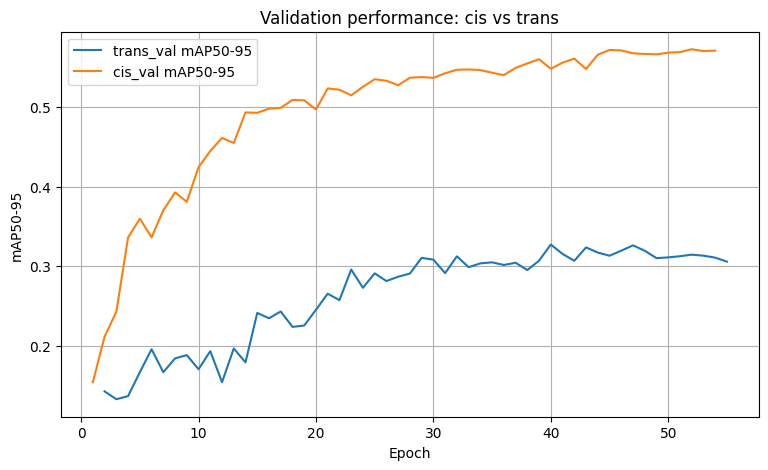

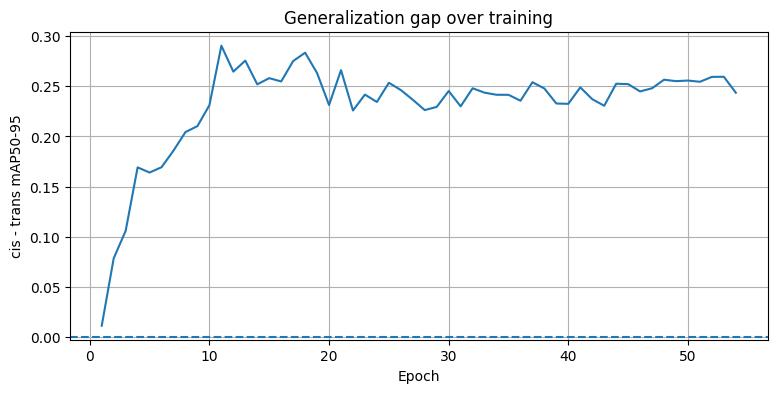

In [22]:

if train_hist is not None:
    plt.figure(figsize=(9, 5))
    x = train_hist["epoch"] + 1 if "epoch" in train_hist.columns else np.arange(1, len(train_hist) + 1)
    if "metrics/mAP50-95(B)" in train_hist.columns:
        plt.plot(x, train_hist["metrics/mAP50-95(B)"], label="trans_val mAP50-95")
    if cis_hist is not None and "cis_mAP50_95" in cis_hist.columns:
        plt.plot(cis_hist["epoch"], cis_hist["cis_mAP50_95"], label="cis_val mAP50-95")
    plt.xlabel("Epoch")
    plt.ylabel("mAP50-95")
    plt.title("Validation performance: cis vs trans")
    plt.legend()
    plt.grid(True)
    plt.show()

if cis_hist is not None and "cis_minus_trans_gap" in cis_hist.columns:
    plt.figure(figsize=(9, 4))
    plt.plot(cis_hist["epoch"], cis_hist["cis_minus_trans_gap"])
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Epoch")
    plt.ylabel("cis - trans mAP50-95")
    plt.title("Generalization gap over training")
    plt.grid(True)
    plt.show()


## 11) Evaluate the best checkpoint on both test splits

In [23]:
best_model_path = BEST_CKPT if BEST_CKPT.exists() else LAST_CKPT
best_model = YOLO(str(best_model_path))

def evaluate_split(model, data_yaml, split_name, imgsz=IMG_SIZE, batch=BATCH):
    metrics = model.val(
        data=str(data_yaml),
        split="val",
        imgsz=imgsz,
        batch=batch,
        plots=False,
        save_json=False,
        verbose=True,
    )
    metrics_dict = metrics_to_dict(metrics)
    box = getattr(metrics, "box", None)
    row = {
        "split": split_name,
        "mAP50": float(metrics_dict.get("metrics/mAP50(B)", getattr(box, "map50", np.nan))),
        "mAP50_95": float(metrics_dict.get("metrics/mAP50-95(B)", getattr(box, "map", np.nan))),
        "precision": float(metrics_dict.get("metrics/precision(B)", getattr(box, "mp", np.nan))),
        "recall": float(metrics_dict.get("metrics/recall(B)", getattr(box, "mr", np.nan))),
    }
    return row, metrics

eval_rows = []
cis_test_row, cis_test_metrics = evaluate_split(best_model, CIS_TEST_YAML, "cis_test")
eval_rows.append(cis_test_row)

trans_test_row, trans_test_metrics = evaluate_split(best_model, TRANS_TEST_YAML, "trans_test")
eval_rows.append(trans_test_row)

eval_df = pd.DataFrame(eval_rows)
eval_df.to_csv(ARTIFACT_DIR / "test_metrics.csv", index=False)
eval_df



Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
custom_YOLO11s_wildlife summary (fused): 118 layers, 9,813,718 parameters, 0 gradients, 21.7 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.2 ms, read: 11.1±0.5 MB/s, size: 87.6 KB)
val: Scanning /kaggle/working/wildlife_yolo11_biasaware/dataset_yolo/labels/cis_test... 15827 images, 3131 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15827/15827 360.0it/s 44.0s<0.0s
val: New cache created: /kaggle/working/wildlife_yolo11_biasaware/dataset_yolo/labels/cis_test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1979/1979 12.3it/s 2:41<0.1s
                   all      15827      13264      0.735      0.742      0.769      0.487
               opossum       3999       4010      0.963      0.819      0.949      0.503
               raccoon        925        981      0.723      0.947      0.913      0.565
              squirrel        503        510      

,split,mAP50,mAP50_95,precision,recall
0,cis_test,0.769448,0.486633,0.735096,0.741782
1,trans_test,0.484081,0.304591,0.573965,0.480153


## 12) Visualize predictions

This section shows a few prediction examples from both the same-location and cross-location test splits.

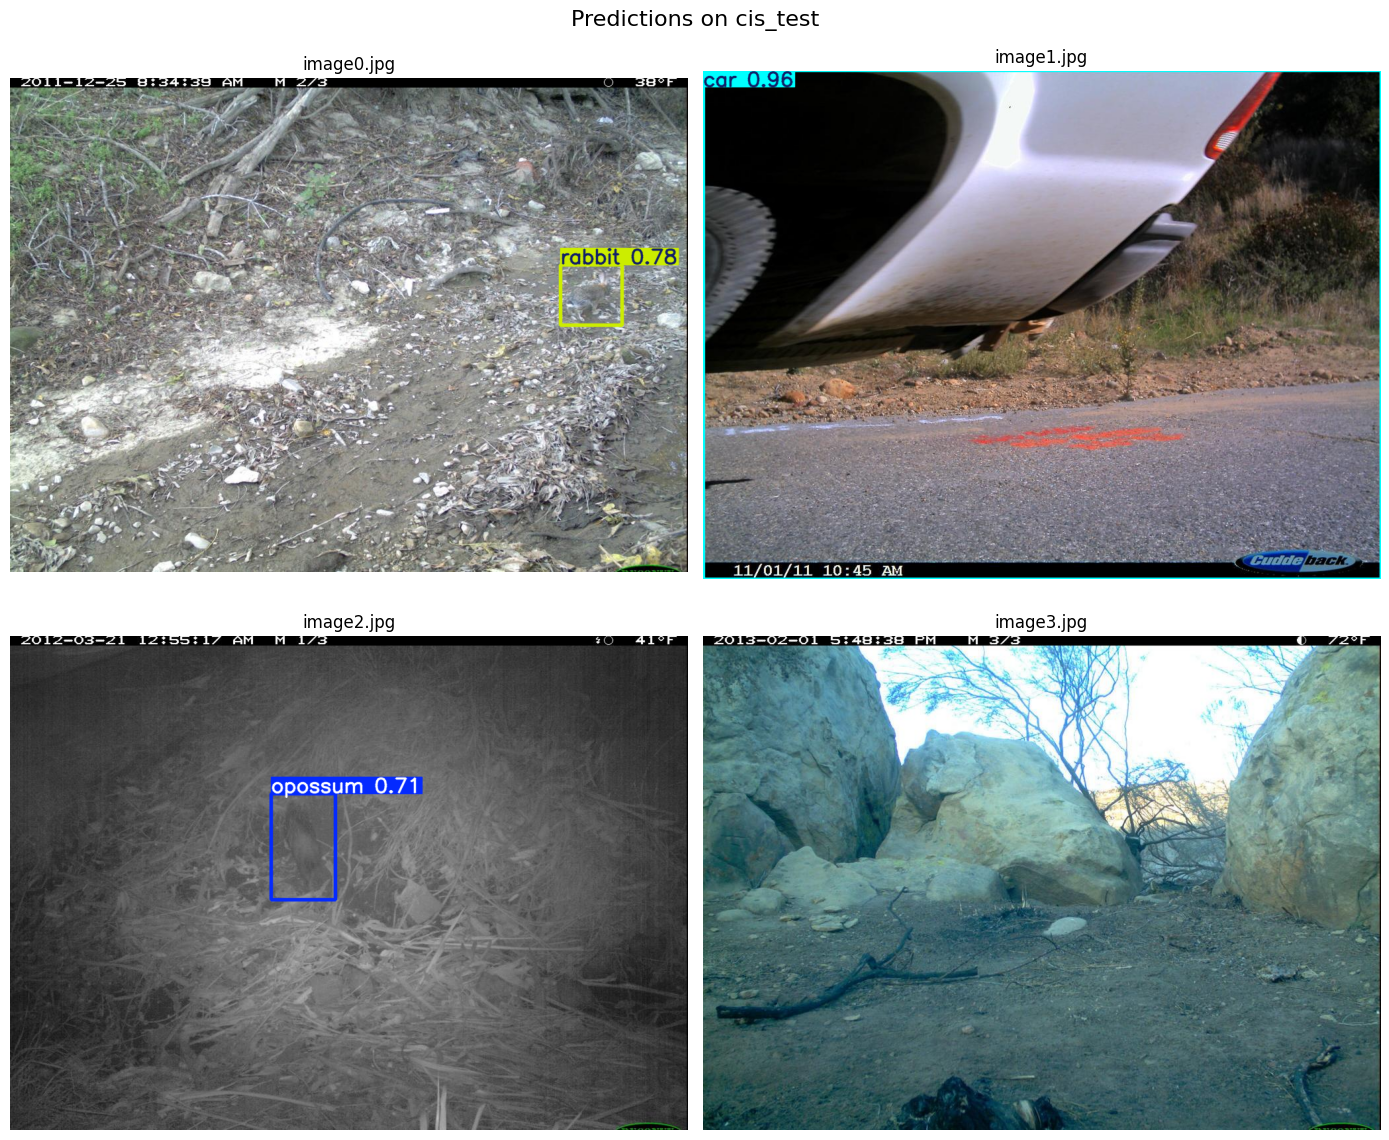

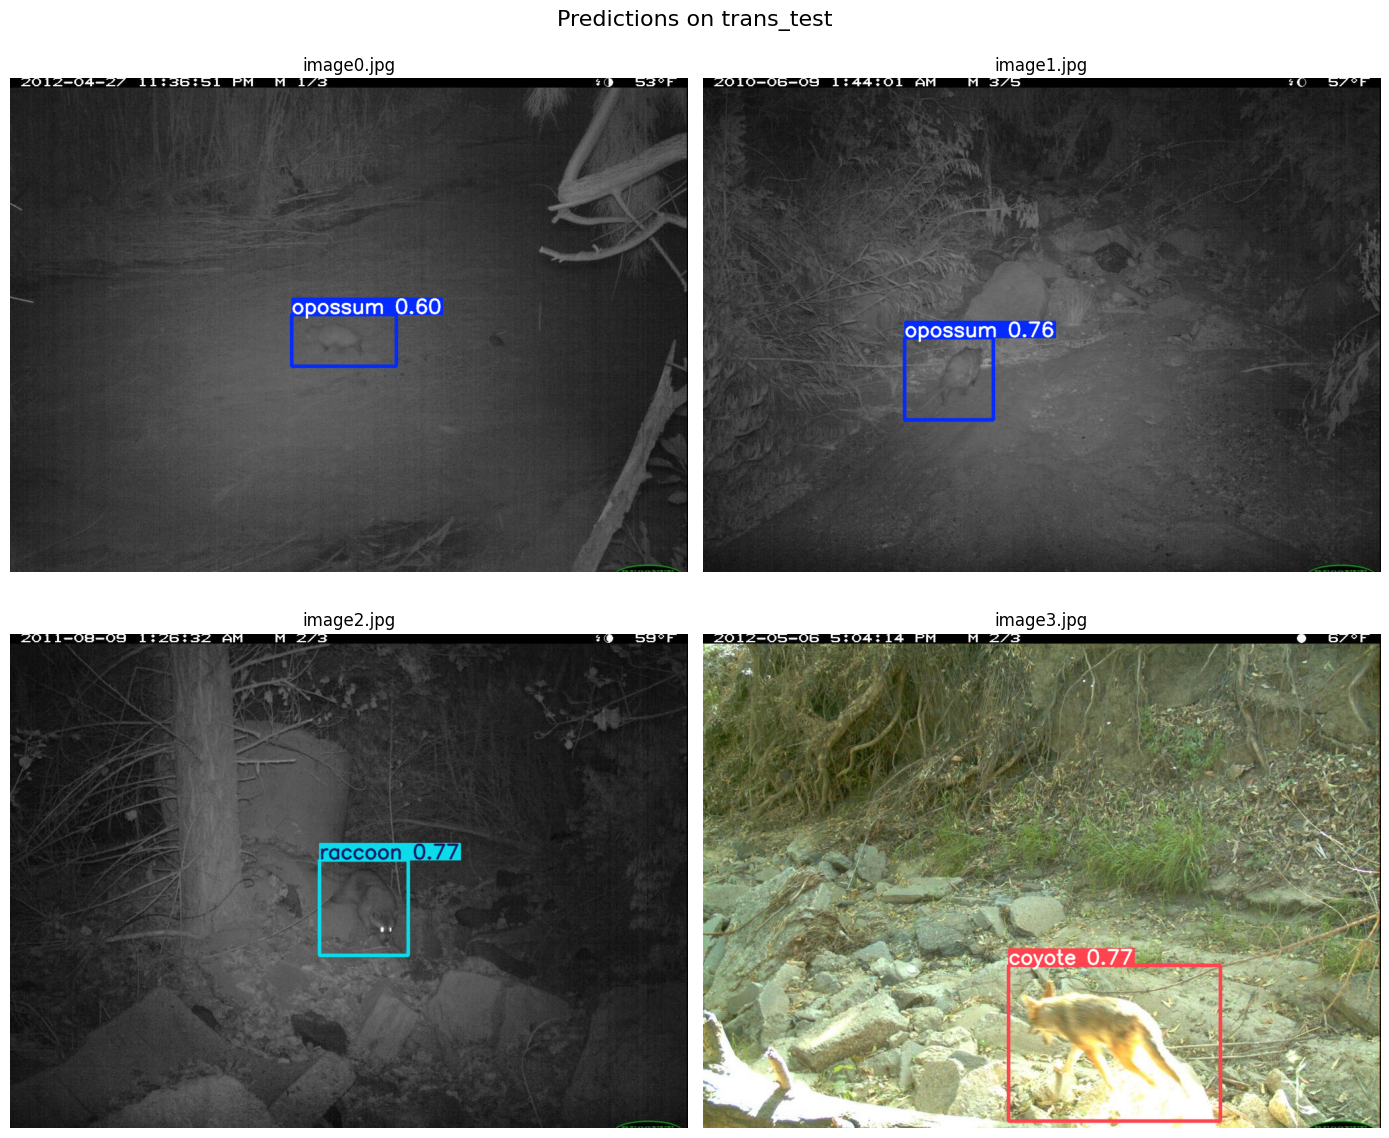

In [24]:

def sample_images(split_name, n=4):
    image_paths = sorted((IMAGES_DIR / split_name).glob("*"))
    if len(image_paths) == 0:
        return []
    n = min(n, len(image_paths))
    random.seed(SEED)
    return random.sample(image_paths, n)

def show_predictions(model, image_paths, title, conf=0.25):
    if len(image_paths) == 0:
        print(f"No images available for {title}")
        return
    results = model.predict(
        source=[str(p) for p in image_paths],
        conf=conf,
        imgsz=IMG_SIZE,
        save=False,
        verbose=False,
    )
    n = len(results)
    cols = 2
    rows = math.ceil(n / cols)
    plt.figure(figsize=(14, 6 * rows))
    for i, r in enumerate(results, start=1):
        plt.subplot(rows, cols, i)
        plt.imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.title(Path(r.path).name)
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

cis_sample = sample_images("cis_test", n=4)
trans_sample = sample_images("trans_test", n=4)

show_predictions(best_model, cis_sample, "Predictions on cis_test")
show_predictions(best_model, trans_sample, "Predictions on trans_test")
